# Conectividade em IoT: Wi-Fi, Mesh, Zigbee/RPL e LoRaWAN

> Se eu tenho 200 sensores espalhados em uma fazenda, em uma indústria ou em um prédio, faz sentido conectar todos por Wi-Fi?

A resposta é: **depende**. Em IoT, a escolha da conectividade não é apenas uma questão de "qual rede está disponível". Ela depende de restrições como:

- alcance;
- energia;
- taxa de dados;
- quantidade de dispositivos;
- topologia;
- necessidade de IP;
- latência;
- custo;
- robustez.

Neste notebook, vamos usar modelos geométricos simples para discutir conectividade, topologia e trade-offs. Os termos **Zigbee-like**, **RPL-like** e **LoRaWAN-like** significam modelos didáticos aproximados. O notebook **não implementa Zigbee real, RPL real ou LoRaWAN real**.

| Estratégia | Ideia central | Uso típico |
|---|---|---|
| Wi-Fi-like | cada sensor fala diretamente com um AP/gateway | alta taxa, menor número de dispositivos |
| Mesh | nós encaminham mensagens uns dos outros | redes locais de baixo consumo |
| Zigbee-like | pilha local de baixo consumo, frequentemente mesh | automação residencial/predial |
| RPL-like | roteamento IPv6 multi-hop para redes restritas | redes 6LoWPAN/IoT acadêmicas/industriais |
| LoRaWAN-like | longo alcance, estrela-de-estrelas, baixa taxa | sensores remotos e esparsos |

## 1. Ideia da aula

A meta é construir intuição visual:

- **estrela**: cada nó precisa falar diretamente com o gateway;
- **mesh**: nós próximos podem encaminhar mensagens em múltiplos saltos;
- **RPL-like**: dentro de uma mesh, podemos escolher uma árvore orientada para um root;
- **Zigbee-like**: podemos interpretar coordinator, routers e end devices de forma conceitual;
- **LoRaWAN-like**: vários gateways de longo alcance recebem mensagens dos end devices, normalmente sem mesh.

Esses modelos são simplificações. Eles ajudam a ensinar topologia, conectividade, alcance e multi-hop, mas não substituem simuladores de protocolo nem medições reais de rádio.

## 2. Imports e configuração global

In [2]:
# Instalação das dependências — execute esta célula apenas uma vez
# %pip instala no kernel ativo (correto para VS Code e Jupyter Lab)
%pip install numpy pandas matplotlib networkx

print('\n✅ Instalação concluída! Execute a próxima célula para importar as bibliotecas.')


✅ Instalação concluída! Execute a próxima célula para importar as bibliotecas.




[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2.1. Cenário

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from dataclasses import dataclass

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


@dataclass
class ScenarioConfig:
    '''Parâmetros geométricos do cenário didático.'''

    n_nodes: int = 200
    area_size: float = 1000.0
    wifi_radius: float = 220.0
    mesh_radius: float = 110.0
    lora_radius: float = 750.0
    n_gateways_lora: int = 3


config = ScenarioConfig()
config

ScenarioConfig(n_nodes=200, area_size=1000.0, wifi_radius=220.0, mesh_radius=110.0, lora_radius=750.0, n_gateways_lora=3)

## 3. Geração do cenário espacial

Vamos distribuir os sensores em uma região quadrada. O gateway Wi-Fi/mesh ficará no centro. Para LoRaWAN-like, usaremos múltiplos gateways para representar a ideia de **estrela-de-estrelas**.

O modelo é geométrico e simplificado: ele considera apenas posições e raios de comunicação. Não há perda por obstáculo, interferência, canal, potência, antena, retransmissão ou disputa pelo meio.

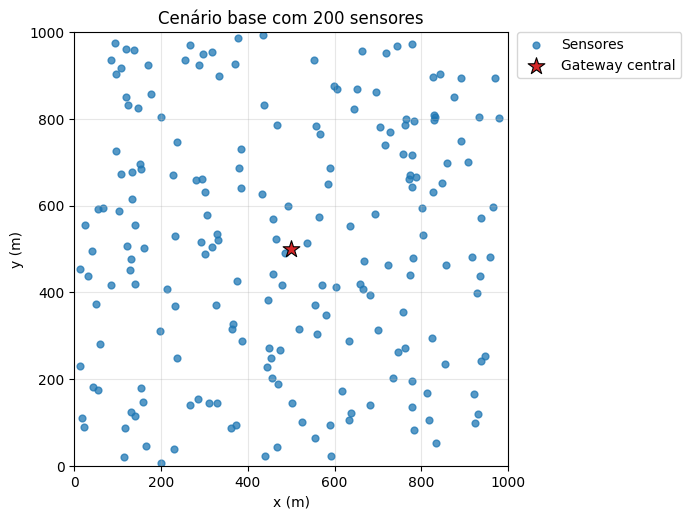

Quantidade de sensores gerados: 200


In [4]:
def generate_sensor_positions(config: ScenarioConfig, seed: int = 42) -> np.ndarray:
    '''Gera posições uniformes dos sensores em uma área quadrada.'''
    local_rng = np.random.default_rng(seed)
    return local_rng.uniform(0, config.area_size, size=(config.n_nodes, 2))


def central_gateway(config: ScenarioConfig) -> np.ndarray:
    '''Retorna um gateway no centro da área.'''
    center = config.area_size / 2.0
    return np.array([[center, center]], dtype=float)


def lora_gateways(config: ScenarioConfig) -> np.ndarray:
    '''Retorna posições determinísticas para gateways LoRaWAN-like.'''
    size = config.area_size
    base_positions = np.array(
        [
            [0.50 * size, 0.50 * size],
            [0.18 * size, 0.18 * size],
            [0.82 * size, 0.82 * size],
            [0.18 * size, 0.82 * size],
            [0.82 * size, 0.18 * size],
        ],
        dtype=float,
    )
    if config.n_gateways_lora <= len(base_positions):
        return base_positions[: config.n_gateways_lora]

    extra_count = config.n_gateways_lora - len(base_positions)
    angles = np.linspace(0, 2 * np.pi, extra_count, endpoint=False)
    radius = 0.32 * size
    center = np.array([0.5 * size, 0.5 * size])
    extras = np.column_stack((np.cos(angles), np.sin(angles))) * radius + center
    return np.vstack([base_positions, extras])


def plot_scenario(
    positions: np.ndarray,
    gateway: np.ndarray,
    lora_gws: np.ndarray | None = None,
    title: str = "Cenário IoT",
    area_size: float | None = None,
) -> None:
    '''Plota sensores e gateways do cenário.'''
    if area_size is None:
        arrays = [positions, gateway]
        if lora_gws is not None:
            arrays.append(lora_gws)
        area_size = float(max(np.max(arr) for arr in arrays))

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(positions[:, 0], positions[:, 1], s=24, alpha=0.75, label="Sensores")
    ax.scatter(
        gateway[:, 0],
        gateway[:, 1],
        s=160,
        marker="*",
        color="tab:red",
        edgecolor="black",
        linewidth=0.8,
        label="Gateway central",
        zorder=5,
    )
    if lora_gws is not None:
        ax.scatter(
            lora_gws[:, 0],
            lora_gws[:, 1],
            s=110,
            marker="s",
            color="tab:green",
            edgecolor="black",
            linewidth=0.8,
            label="Gateways LoRaWAN-like",
            zorder=4,
        )
    ax.set_xlim(0, area_size)
    ax.set_ylim(0, area_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.tight_layout()
    plt.show()


positions = generate_sensor_positions(config, seed=RANDOM_SEED)
gateway = central_gateway(config)
lora_gws = lora_gateways(config)

plot_scenario(
    positions,
    gateway,
    title="Cenário base com 200 sensores",
    area_size=config.area_size,
)

print(f"Quantidade de sensores gerados: {len(positions)}")

O cenário acima será usado em todos os modelos. Assim, quando compararmos Wi-Fi-like, mesh, RPL-like e LoRaWAN-like, estaremos olhando para os mesmos 200 sensores.

## 4. Modelo Wi-Fi-like: estrela com alcance direto

No modelo estrela, cada sensor precisa falar diretamente com o gateway. A simulação abaixo representa uma rede Wi-Fi-like de forma simplificada: existe conexão apenas se a distância do sensor ao gateway for menor ou igual ao raio.

Esse não é um modelo físico de Wi-Fi. Ele ignora interferência, capacidade do AP, associação, potência, obstáculos e taxa de transmissão.

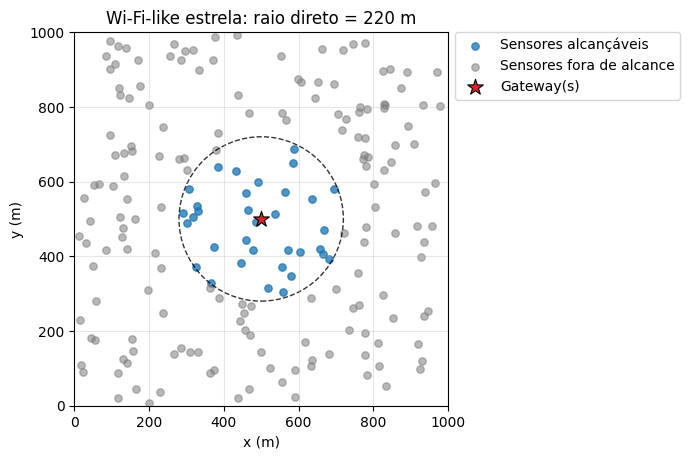

Sensores alcançados: 34 de 200
Porcentagem alcançada: 17.0%
Sensores fora de alcance: 166


In [5]:
def direct_reachability(
    positions: np.ndarray, gateways: np.ndarray, radius: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''
    Calcula quais sensores alcançam pelo menos um gateway diretamente.

    positions: array n x 2
    gateways: array k x 2
    radius: float
    Retorna:
        reachable: boolean array n
        nearest_gateway: int array n
        min_distances: float array n
    '''
    deltas = positions[:, np.newaxis, :] - gateways[np.newaxis, :, :]
    distances = np.linalg.norm(deltas, axis=2)
    nearest_gateway = np.argmin(distances, axis=1)
    min_distances = distances[np.arange(len(positions)), nearest_gateway]
    reachable = min_distances <= radius
    return reachable, nearest_gateway, min_distances


def plot_direct_model(
    positions: np.ndarray,
    gateways: np.ndarray,
    reachable: np.ndarray,
    radius: float,
    title: str,
    area_size: float | None = None,
) -> None:
    '''Plota um modelo estrela com círculos de alcance.'''
    if area_size is None:
        area_size = float(max(np.max(positions), np.max(gateways)))

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(
        positions[reachable, 0],
        positions[reachable, 1],
        s=28,
        alpha=0.78,
        label="Sensores alcançáveis",
    )
    ax.scatter(
        positions[~reachable, 0],
        positions[~reachable, 1],
        s=28,
        alpha=0.55,
        color="tab:gray",
        label="Sensores fora de alcance",
    )
    ax.scatter(
        gateways[:, 0],
        gateways[:, 1],
        s=140,
        marker="*",
        color="tab:red",
        edgecolor="black",
        linewidth=0.8,
        label="Gateway(s)",
        zorder=5,
    )
    for gw in gateways:
        circle = plt.Circle(gw, radius, fill=False, linestyle="--", alpha=0.8)
        ax.add_patch(circle)
    ax.set_xlim(0, area_size)
    ax.set_ylim(0, area_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.tight_layout()
    plt.show()


wifi_reachable, wifi_nearest_gateway, wifi_distances = direct_reachability(
    positions, gateway, config.wifi_radius
)

plot_direct_model(
    positions,
    gateway,
    wifi_reachable,
    config.wifi_radius,
    title=f"Wi-Fi-like estrela: raio direto = {config.wifi_radius:.0f} m",
    area_size=config.area_size,
)

wifi_count = int(wifi_reachable.sum())
wifi_fraction = wifi_count / config.n_nodes
wifi_disconnected = config.n_nodes - wifi_count

print(f"Sensores alcançados: {wifi_count} de {config.n_nodes}")
print(f"Porcentagem alcançada: {100 * wifi_fraction:.1f}%")
print(f"Sensores fora de alcance: {wifi_disconnected}")

Se muitos sensores ficam fora de alcance, uma estrela simples pode ser inadequada. Aumentar o alcance direto pode exigir mais infraestrutura, maior potência, melhor posicionamento de gateways, maior custo ou aceitar mais interferência.

O ponto didático é simples: uma rede estrela é fácil de entender e operar, mas depende fortemente de cobertura direta.

## 5. Modelo mesh: conectividade por múltiplos saltos

Em uma rede **mesh**, sensores ou roteadores podem encaminhar mensagens uns dos outros. Um nó não precisa alcançar diretamente o gateway; basta existir um caminho multi-hop até ele.

Isso pode aumentar a cobertura usando enlaces de menor alcance. Por outro lado, multi-hop também pode aumentar latência, tráfego de controle, consumo dos nós roteadores e complexidade de roteamento.

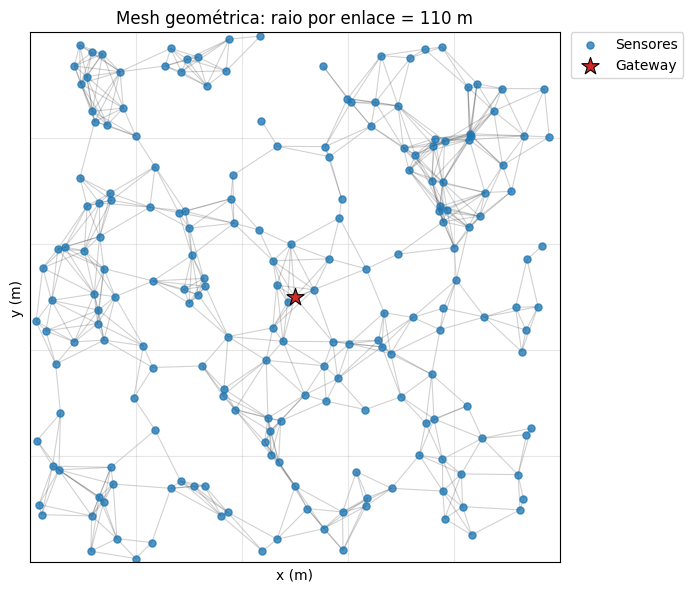

,reachable_count,reachable_fraction,disconnected_count,connected_components,average_degree,number_of_edges,average_hops_to_gateway,max_hops_to_gateway,average_weighted_distance_to_gateway
0,200,1.0,0,1,6.835821,687,5.37,11,438.270997


In [6]:
def build_geometric_graph(
    positions: np.ndarray, gateway: np.ndarray, radius: float
) -> tuple[nx.Graph, int, np.ndarray]:
    '''
    Cria um grafo geométrico não direcionado.

    Nós 0..n-1 são sensores.
    Nó n é o gateway.
    Há aresta entre dois nós se distância <= radius.
    Peso da aresta = distância euclidiana.
    Retorna:
        G, gateway_id, all_positions
    '''
    all_positions = np.vstack([positions, gateway])
    n_sensors = len(positions)
    gateway_id = n_sensors
    G = nx.Graph()

    for node_id, xy in enumerate(all_positions):
        G.add_node(node_id, pos=xy, kind="gateway" if node_id == gateway_id else "sensor")

    for i in range(len(all_positions)):
        for j in range(i + 1, len(all_positions)):
            distance = float(np.linalg.norm(all_positions[i] - all_positions[j]))
            if distance <= radius:
                G.add_edge(i, j, weight=distance)

    return G, gateway_id, all_positions


def mesh_metrics(G: nx.Graph, gateway_id: int, n_sensors: int) -> dict:
    '''
    Calcula métricas simples de conectividade para a mesh.

    Inclui alcance, componentes, grau médio, enlaces, saltos até o gateway
    e distância ponderada pelos enlaces.
    '''
    hop_lengths = nx.single_source_shortest_path_length(G, gateway_id)
    weighted_lengths = nx.single_source_dijkstra_path_length(G, gateway_id, weight="weight")

    reachable_sensor_nodes = [node for node in range(n_sensors) if node in hop_lengths]
    reachable_count = len(reachable_sensor_nodes)
    hop_values = [hop_lengths[node] for node in reachable_sensor_nodes]
    weighted_values = [weighted_lengths[node] for node in reachable_sensor_nodes]

    degrees = [degree for _, degree in G.degree()]
    return {
        "reachable_count": reachable_count,
        "reachable_fraction": reachable_count / n_sensors,
        "disconnected_count": n_sensors - reachable_count,
        "connected_components": nx.number_connected_components(G),
        "average_degree": float(np.mean(degrees)) if degrees else 0.0,
        "number_of_edges": G.number_of_edges(),
        "average_hops_to_gateway": float(np.mean(hop_values)) if hop_values else np.nan,
        "max_hops_to_gateway": int(np.max(hop_values)) if hop_values else 0,
        "average_weighted_distance_to_gateway": float(np.mean(weighted_values))
        if weighted_values
        else np.nan,
    }


def plot_mesh_graph(
    G: nx.Graph,
    all_positions: np.ndarray,
    gateway_id: int,
    title: str,
    max_edges_to_draw: int | None = None,
    area_size: float | None = None,
) -> None:
    '''Plota o grafo mesh com arestas discretas para manter legibilidade.'''
    if area_size is None:
        area_size = float(np.max(all_positions))

    pos = {node: all_positions[node] for node in G.nodes}
    edges = list(G.edges())
    if max_edges_to_draw is not None and len(edges) > max_edges_to_draw:
        local_rng = np.random.default_rng(RANDOM_SEED)
        selected = local_rng.choice(len(edges), size=max_edges_to_draw, replace=False)
        edges = [edges[i] for i in selected]

    sensor_nodes = [node for node in G.nodes if node != gateway_id]

    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax, alpha=0.18, width=0.8)
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=sensor_nodes,
        node_size=26,
        node_color="tab:blue",
        alpha=0.78,
        ax=ax,
        label="Sensores",
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[gateway_id],
        node_size=170,
        node_color="tab:red",
        edgecolors="black",
        linewidths=0.8,
        node_shape="*",
        ax=ax,
        label="Gateway",
    )
    ax.set_xlim(0, area_size)
    ax.set_ylim(0, area_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.tight_layout()
    plt.show()


mesh_graph, mesh_gateway_id, mesh_all_positions = build_geometric_graph(
    positions, gateway, config.mesh_radius
)
mesh_stats = mesh_metrics(mesh_graph, mesh_gateway_id, config.n_nodes)

plot_mesh_graph(
    mesh_graph,
    mesh_all_positions,
    mesh_gateway_id,
    title=f"Mesh geométrica: raio por enlace = {config.mesh_radius:.0f} m",
    max_edges_to_draw=900,
    area_size=config.area_size,
)

mesh_metrics_df = pd.DataFrame([mesh_stats])
mesh_metrics_df

A mesh pode alcançar nós que não falam diretamente com o gateway, desde que exista uma cadeia de vizinhos intermediários. Mesmo usando raio por enlace menor do que no modelo Wi-Fi-like, a cobertura pode melhorar quando a densidade espacial ajuda.

Mas a mesh não faz milagre: se os sensores estiverem muito esparsos, o grafo se fragmenta em componentes desconectados. As métricas de componentes, grau médio e número de enlaces ajudam a enxergar essa fragmentação.

## 6. RPL-like: árvore orientada ao root

RPL real é um protocolo de roteamento IPv6 para **Low-Power and Lossy Networks**. Neste notebook, vamos apenas representar sua ideia central de forma didática:

- o gateway será o **root** ou **border router**;
- cada nó alcançável escolhe um pai em direção ao root;
- a árvore será construída a partir dos caminhos mínimos até o gateway.

Isto **não implementa** DIO, DIS, DAO, rank, trickle timer, objective function real, ETX real ou dinâmica de manutenção de rotas. É uma abstração para visualizar como uma estrutura de roteamento pode ser escolhida dentro de um grafo mesh.

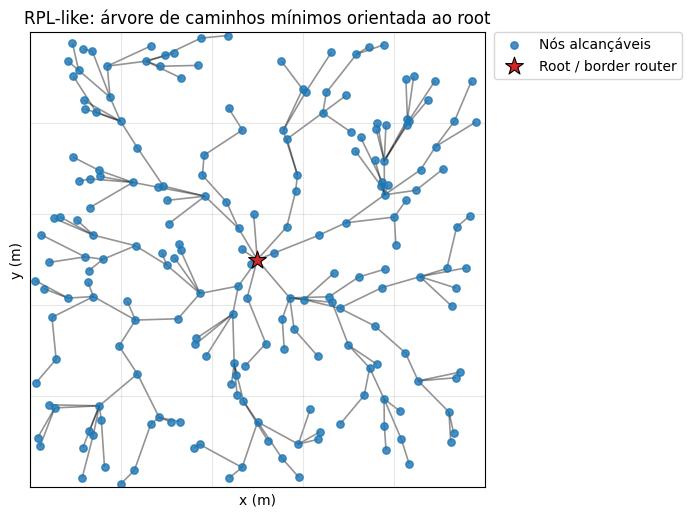

,tree_sensor_nodes,tree_total_nodes,tree_edges,reachable_fraction,max_height_hops,average_depth,leaves,max_degree
0,200,201,200,1.0,11,5.45,98,9


In [7]:
def build_rpl_like_tree(
    G: nx.Graph, gateway_id: int, weight: str = "weight"
) -> tuple[nx.Graph, dict[int, int], dict[int, list[int]]]:
    '''
    Constrói uma árvore RPL-like com base em caminhos mínimos a partir do gateway.

    Para cada nó alcançável:
        pega o caminho do gateway até o nó
        adiciona a aresta entre o nó e seu predecessor no caminho
    Retorna:
        T: nx.Graph
        parent: dict[node] = parent_node
        paths: dict[node] = path
    '''
    paths = nx.single_source_dijkstra_path(G, gateway_id, weight=weight)
    T = nx.Graph()
    parent: dict[int, int] = {}

    for node, data in G.nodes(data=True):
        if node in paths:
            T.add_node(node, **data)

    for node, path in paths.items():
        if node == gateway_id:
            continue
        parent[node] = path[-2]
        edge_weight = G.edges[node, path[-2]].get(weight, 1.0)
        T.add_edge(node, path[-2], weight=edge_weight)

    return T, parent, paths


def rpl_like_metrics(T: nx.Graph, gateway_id: int, n_sensors: int) -> dict:
    '''Calcula métricas simples da árvore RPL-like.'''
    hop_lengths = nx.single_source_shortest_path_length(T, gateway_id)
    sensor_depths = [depth for node, depth in hop_lengths.items() if node != gateway_id]
    leaf_nodes = [
        node for node in T.nodes if node != gateway_id and T.degree(node) == 1
    ]
    degrees = [degree for _, degree in T.degree()]

    return {
        "tree_sensor_nodes": max(T.number_of_nodes() - 1, 0),
        "tree_total_nodes": T.number_of_nodes(),
        "tree_edges": T.number_of_edges(),
        "reachable_fraction": max(T.number_of_nodes() - 1, 0) / n_sensors,
        "max_height_hops": int(np.max(sensor_depths)) if sensor_depths else 0,
        "average_depth": float(np.mean(sensor_depths)) if sensor_depths else np.nan,
        "leaves": len(leaf_nodes),
        "max_degree": int(np.max(degrees)) if degrees else 0,
    }


def plot_rpl_tree(
    T: nx.Graph,
    all_positions: np.ndarray,
    gateway_id: int,
    title: str,
    area_size: float | None = None,
) -> None:
    '''Plota apenas a árvore RPL-like selecionada.'''
    if area_size is None:
        area_size = float(np.max(all_positions))

    pos = {node: all_positions[node] for node in T.nodes}
    sensor_nodes = [node for node in T.nodes if node != gateway_id]

    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_edges(T, pos, ax=ax, alpha=0.42, width=1.2)
    nx.draw_networkx_nodes(
        T,
        pos,
        nodelist=sensor_nodes,
        node_size=28,
        node_color="tab:blue",
        alpha=0.82,
        ax=ax,
        label="Nós alcançáveis",
    )
    nx.draw_networkx_nodes(
        T,
        pos,
        nodelist=[gateway_id],
        node_size=180,
        node_color="tab:red",
        edgecolors="black",
        linewidths=0.8,
        node_shape="*",
        ax=ax,
        label="Root / border router",
    )
    ax.set_xlim(0, area_size)
    ax.set_ylim(0, area_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.tight_layout()
    plt.show()


rpl_tree, rpl_parent, rpl_paths = build_rpl_like_tree(mesh_graph, mesh_gateway_id)
rpl_stats = rpl_like_metrics(rpl_tree, mesh_gateway_id, config.n_nodes)

plot_rpl_tree(
    rpl_tree,
    mesh_all_positions,
    mesh_gateway_id,
    title="RPL-like: árvore de caminhos mínimos orientada ao root",
    area_size=config.area_size,
)

rpl_metrics_df = pd.DataFrame([rpl_stats])
rpl_metrics_df

O grafo mesh representa **enlaces possíveis**. A árvore RPL-like representa uma **estrutura de roteamento escolhida** dentro desses enlaces.

Em protocolos reais, a escolha dos pais pode considerar qualidade do enlace, energia, número esperado de transmissões, rank, políticas da objective function e mudanças ao longo do tempo. Aqui usamos caminho mínimo apenas para tornar a ideia visual e reprodutível.

## 7. Zigbee-like: interpretação conceitual

Zigbee é uma pilha de protocolos sobre IEEE 802.15.4. Ela pode ter papéis como:

- **Coordinator**: coordena a rede;
- **Router**: participa do encaminhamento;
- **End Device**: dispositivo final, frequentemente otimizado para economia de energia.

A simulação mesh anterior pode ser interpretada como uma abstração geométrica compatível com a ideia de uma rede local Zigbee-like. Porém, este notebook **não simula** associação, segurança, perfis de aplicação, APS/NWK, beacons, binding ou roteamento Zigbee real.

Para ficar didaticamente diferente da seção RPL-like, aqui **não vamos usar a árvore RPL-like**. Vamos construir uma abstração própria:

- Coordinator e Routers formam um **backbone mesh**, com vários enlaces possíveis entre roteadores;
- End Devices são desenhados como dispositivos de acesso, cada um ligado a um único pai;
- enlaces entre End Devices são omitidos, mesmo que existam geometricamente, porque eles não representam encaminhamento neste desenho.

Assim, a figura comunica duas ideias separadas: routers encaminham em malha; end devices acessam a rede sem atuar como roteadores.

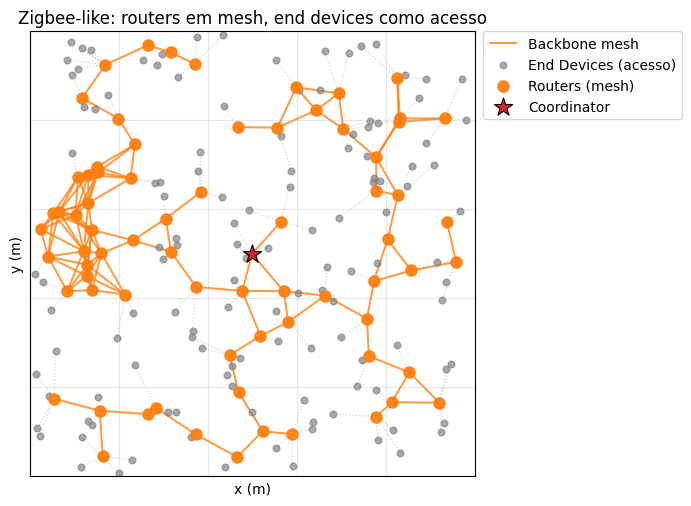

,coordinator,routers,end_devices,disconnected,router_mesh_nodes,router_mesh_edges,router_mesh_connected,router_mesh_extra_edges,average_router_mesh_degree,end_devices_with_one_parent,end_device_edges_hidden
0,1,72,128,0,73,138,True,66,3.780822,128,244


,role,count
0,End Device,128
1,Router,72
2,Coordinator,1


In [8]:
def build_zigbee_like_topology(
    G: nx.Graph, gateway_id: int, target_router_fraction: float = 0.22
) -> tuple[dict[int, str], nx.Graph, list[tuple[int, int]]]:
    '''Constrói um backbone mesh didático para Coordinator e Routers.'''
    connected_nodes = set(nx.node_connected_component(G, gateway_id))
    sensor_nodes = [node for node in connected_nodes if node != gateway_id]
    target_router_count = max(1, int(np.ceil(target_router_fraction * len(sensor_nodes))))
    backbone_nodes = {gateway_id}

    def covered_by_backbone() -> set[int]:
        covered = set(backbone_nodes)
        for node in backbone_nodes:
            covered.update(G.neighbors(node))
        return covered & connected_nodes

    covered = covered_by_backbone()
    uncovered_sensors = set(sensor_nodes)
    while (
        not uncovered_sensors.issubset(covered)
        or (len(backbone_nodes) - 1) < target_router_count
    ):
        frontier = [node for node in covered - backbone_nodes if node != gateway_id]
        if not frontier:
            break

        def score(candidate: int) -> tuple[int, int, int]:
            candidate_cover = set(G.neighbors(candidate)) | {candidate}
            new_coverage = len((candidate_cover & uncovered_sensors) - covered)
            links_to_backbone = sum(
                1 for neighbor in G.neighbors(candidate) if neighbor in backbone_nodes
            )
            return new_coverage, links_to_backbone, G.degree(candidate)

        best = max(frontier, key=score)
        backbone_nodes.add(best)
        covered = covered_by_backbone()
        if backbone_nodes == connected_nodes:
            break

    roles = {}
    for node in G.nodes:
        if node == gateway_id:
            roles[node] = "Coordinator"
        elif node in backbone_nodes:
            roles[node] = "Router"
        elif node in connected_nodes:
            roles[node] = "End Device"
        else:
            roles[node] = "Disconnected"

    access_edges = []
    for node, role in list(roles.items()):
        if role != "End Device":
            continue
        parent_candidates = [neighbor for neighbor in G.neighbors(node) if neighbor in backbone_nodes]
        if not parent_candidates:
            roles[node] = "Disconnected"
            continue
        parent = min(
            parent_candidates,
            key=lambda neighbor: G.edges[node, neighbor].get("weight", 1.0),
        )
        access_edges.append((node, parent))

    router_mesh = G.subgraph(backbone_nodes).copy()
    return roles, router_mesh, access_edges


def zigbee_like_metrics(
    G: nx.Graph,
    router_mesh: nx.Graph,
    access_edges: list[tuple[int, int]],
    roles: dict[int, str],
) -> dict:
    '''Calcula métricas para validar o backbone mesh Zigbee-like.'''
    end_devices = [node for node, role in roles.items() if role == "End Device"]
    hidden_end_device_edges = [
        (u, v)
        for u, v in G.edges
        if roles.get(u) == "End Device" and roles.get(v) == "End Device"
    ]
    router_degrees = [degree for _, degree in router_mesh.degree()]

    return {
        "coordinator": 1,
        "routers": sum(role == "Router" for role in roles.values()),
        "end_devices": len(end_devices),
        "disconnected": sum(role == "Disconnected" for role in roles.values()),
        "router_mesh_nodes": router_mesh.number_of_nodes(),
        "router_mesh_edges": router_mesh.number_of_edges(),
        "router_mesh_connected": nx.is_connected(router_mesh)
        if router_mesh.number_of_nodes() > 0
        else False,
        "router_mesh_extra_edges": router_mesh.number_of_edges()
        - max(router_mesh.number_of_nodes() - 1, 0),
        "average_router_mesh_degree": float(np.mean(router_degrees))
        if router_degrees
        else 0.0,
        "end_devices_with_one_parent": len(access_edges),
        "end_device_edges_hidden": len(hidden_end_device_edges),
    }


def plot_zigbee_like_roles(
    G: nx.Graph,
    router_mesh: nx.Graph,
    access_edges: list[tuple[int, int]],
    all_positions: np.ndarray,
    gateway_id: int,
    roles: dict[int, str],
    title: str,
    area_size: float | None = None,
) -> None:
    '''Plota routers como mesh e end devices como acesso de borda.'''
    if area_size is None:
        area_size = float(np.max(all_positions))

    pos = {node: all_positions[node] for node in G.nodes}
    routers = [node for node, role in roles.items() if role == "Router"]
    end_devices = [node for node, role in roles.items() if role == "End Device"]
    disconnected = [node for node, role in roles.items() if role == "Disconnected"]

    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_edges(
        router_mesh,
        pos,
        edgelist=list(router_mesh.edges()),
        ax=ax,
        alpha=0.78,
        width=1.45,
        edge_color="tab:orange",
        label="Backbone mesh",
    )
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=access_edges,
        ax=ax,
        alpha=0.34,
        width=0.85,
        style="dotted",
        edge_color="tab:gray",
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=end_devices,
        node_size=23,
        node_color="tab:gray",
        alpha=0.66,
        ax=ax,
        label="End Devices (acesso)",
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=routers,
        node_size=64,
        node_color="tab:orange",
        alpha=0.94,
        ax=ax,
        label="Routers (mesh)",
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[gateway_id],
        node_size=190,
        node_color="tab:red",
        edgecolors="black",
        linewidths=0.8,
        node_shape="*",
        ax=ax,
        label="Coordinator",
    )
    if disconnected:
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=disconnected,
            node_size=24,
            node_color="white",
            edgecolors="tab:gray",
            linewidths=0.8,
            ax=ax,
            label="Desconectados",
        )
    ax.set_xlim(0, area_size)
    ax.set_ylim(0, area_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.tight_layout()
    plt.show()


zigbee_roles, zigbee_router_mesh, zigbee_access_edges = build_zigbee_like_topology(
    mesh_graph, mesh_gateway_id, target_router_fraction=0.36
)
zigbee_stats = zigbee_like_metrics(
    mesh_graph, zigbee_router_mesh, zigbee_access_edges, zigbee_roles
)

plot_zigbee_like_roles(
    mesh_graph,
    zigbee_router_mesh,
    zigbee_access_edges,
    mesh_all_positions,
    mesh_gateway_id,
    zigbee_roles,
    title="Zigbee-like: routers em mesh, end devices como acesso",
    area_size=config.area_size,
)

display(pd.DataFrame([zigbee_stats]))
pd.Series(zigbee_roles).value_counts().rename_axis("role").reset_index(name="count")

Nesta leitura didática, os routers formam uma mesh local conectada ao coordinator. A figura desenha os enlaces geométricos disponíveis entre Coordinator e Routers, criando ciclos e caminhos alternativos no backbone.

Os end devices aparecem como dispositivos de acesso: cada um tem um enlace pontilhado até um pai, que pode ser um router ou o próprio coordinator. Enlaces entre end devices foram omitidos de propósito. Eles poderiam estar dentro do raio geométrico, mas não representam encaminhamento neste modelo didático.

Essa seção agora é deliberadamente diferente da RPL-like: RPL-like mostra uma **árvore de roteamento escolhida**; Zigbee-like mostra uma **malha local de routers** com end devices na borda.

## 8. LoRaWAN-like: estrela-de-estrelas de longo alcance

LoRa é uma tecnologia física/modulação. LoRaWAN define uma arquitetura de rede sobre LoRa.

Em uso típico, LoRaWAN **não é mesh**:

- end devices enviam mensagens para gateways;
- gateways encaminham para servidores via rede IP;
- vários gateways podem ouvir o mesmo dispositivo;
- a topologia é frequentemente descrita como **estrela-de-estrelas**.

A vantagem é longo alcance e baixo consumo para mensagens pequenas e esparsas. A desvantagem é baixa taxa de dados, limitações regulatórias/de duty cycle em muitos contextos e menor adequação para tráfego intenso.

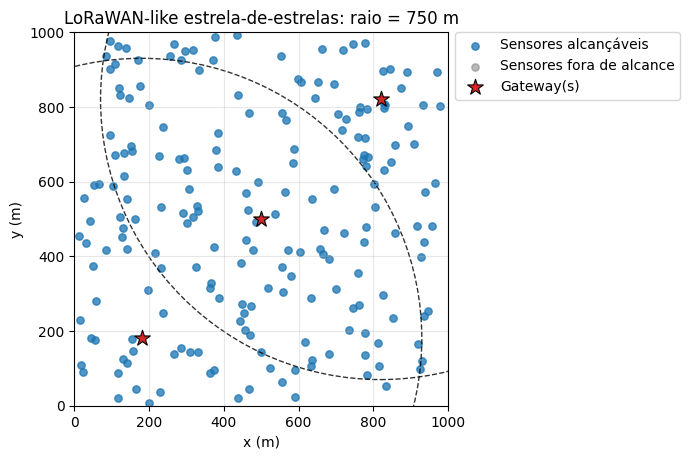

,reachable_count,reachable_fraction,disconnected_count,average_distance_to_nearest_gateway,max_distance_to_nearest_gateway,gateways_count,average_hops,max_hops
0,200,1.0,0,266.385723,625.226876,3,1.0,1


In [9]:
def lorawan_like_metrics(
    positions: np.ndarray, gateways: np.ndarray, radius: float
) -> dict:
    '''
    Calcula métricas para uma estrela-de-estrelas LoRaWAN-like.

    Retorna:
    - reachable_count
    - reachable_fraction
    - disconnected_count
    - average_distance_to_nearest_gateway
    - max_distance_to_nearest_gateway
    - gateways_count
    - hops = 1 para nós alcançáveis
    '''
    reachable, nearest_gateway, min_distances = direct_reachability(
        positions, gateways, radius
    )
    reachable_distances = min_distances[reachable]
    return {
        "reachable_count": int(reachable.sum()),
        "reachable_fraction": float(reachable.mean()),
        "disconnected_count": int((~reachable).sum()),
        "average_distance_to_nearest_gateway": float(np.mean(reachable_distances))
        if len(reachable_distances)
        else np.nan,
        "max_distance_to_nearest_gateway": float(np.max(reachable_distances))
        if len(reachable_distances)
        else np.nan,
        "gateways_count": len(gateways),
        "average_hops": 1.0 if reachable.any() else np.nan,
        "max_hops": 1 if reachable.any() else 0,
    }


lora_reachable, lora_nearest_gateway, lora_distances = direct_reachability(
    positions, lora_gws, config.lora_radius
)
lora_stats = lorawan_like_metrics(positions, lora_gws, config.lora_radius)

plot_direct_model(
    positions,
    lora_gws,
    lora_reachable,
    config.lora_radius,
    title=f"LoRaWAN-like estrela-de-estrelas: raio = {config.lora_radius:.0f} m",
    area_size=config.area_size,
)

pd.DataFrame([lora_stats])

A comparação central é:

- **Mesh**: vários saltos, menor raio por enlace, sensores/roteadores podem encaminhar mensagens.
- **LoRaWAN-like**: um salto até algum gateway, raio maior, sem encaminhamento entre sensores no modelo típico.

Por isso, não devemos dizer que LoRaWAN é mesh. Ele resolve outro tipo de problema: alcance amplo com mensagens pequenas e pouco frequentes.

## 9. Comparação: estrela, mesh, RPL-like e LoRaWAN-like

In [10]:
def consolidated_comparison() -> pd.DataFrame:
    '''Cria tabela comparativa dos modelos simulados.'''
    rows = [
        {
            "model": "Wi-Fi-like estrela",
            "radius": config.wifi_radius,
            "gateways": 1,
            "reachable_count": wifi_count,
            "reachable_fraction": wifi_fraction,
            "disconnected_count": wifi_disconnected,
            "average_hops": 1.0 if wifi_count else np.nan,
            "max_hops": 1 if wifi_count else 0,
            "average_degree": np.nan,
            "edges": wifi_count,
            "notes": "alcance direto até AP/gateway",
        },
        {
            "model": "Mesh geométrica",
            "radius": config.mesh_radius,
            "gateways": 1,
            "reachable_count": mesh_stats["reachable_count"],
            "reachable_fraction": mesh_stats["reachable_fraction"],
            "disconnected_count": mesh_stats["disconnected_count"],
            "average_hops": mesh_stats["average_hops_to_gateway"],
            "max_hops": mesh_stats["max_hops_to_gateway"],
            "average_degree": mesh_stats["average_degree"],
            "edges": mesh_stats["number_of_edges"],
            "notes": "multi-hop em grafo de proximidade",
        },
        {
            "model": "RPL-like árvore",
            "radius": config.mesh_radius,
            "gateways": 1,
            "reachable_count": rpl_stats["tree_sensor_nodes"],
            "reachable_fraction": rpl_stats["reachable_fraction"],
            "disconnected_count": config.n_nodes - rpl_stats["tree_sensor_nodes"],
            "average_hops": rpl_stats["average_depth"],
            "max_hops": rpl_stats["max_height_hops"],
            "average_degree": float(np.mean([degree for _, degree in rpl_tree.degree()]))
            if rpl_tree.number_of_nodes()
            else np.nan,
            "edges": rpl_stats["tree_edges"],
            "notes": "estrutura de roteamento escolhida na mesh",
        },
        {
            "model": "LoRaWAN-like estrela-de-estrelas",
            "radius": config.lora_radius,
            "gateways": config.n_gateways_lora,
            "reachable_count": lora_stats["reachable_count"],
            "reachable_fraction": lora_stats["reachable_fraction"],
            "disconnected_count": lora_stats["disconnected_count"],
            "average_hops": lora_stats["average_hops"],
            "max_hops": lora_stats["max_hops"],
            "average_degree": np.nan,
            "edges": lora_stats["reachable_count"],
            "notes": "longo alcance, sem mesh entre sensores",
        },
    ]
    return pd.DataFrame(rows)


comparison_df = consolidated_comparison()
comparison_df

,model,radius,gateways,reachable_count,reachable_fraction,disconnected_count,average_hops,max_hops,average_degree,edges,notes
0,Wi-Fi-like estrela,220.0,1,34,0.17,166,1.00,1,NaN,34,alcance direto até AP/gateway
1,Mesh geométrica,110.0,1,200,1.00,0,5.37,11,6.835821,687,multi-hop em grafo de proximidade
2,RPL-like árvore,110.0,1,200,1.00,0,5.45,11,1.990050,200,estrutura de roteamento escolhida na mesh
3,LoRaWAN-like estrela-de-estrelas,750.0,3,200,1.00,0,1.00,1,NaN,200,"longo alcance, sem mesh entre sensores"


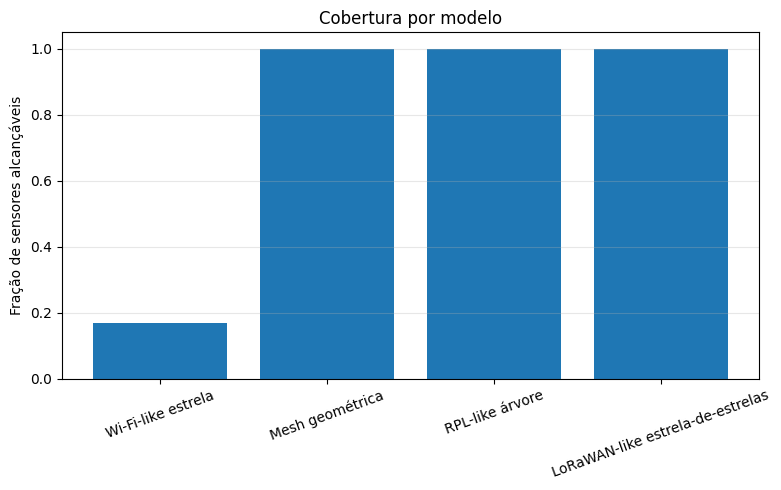

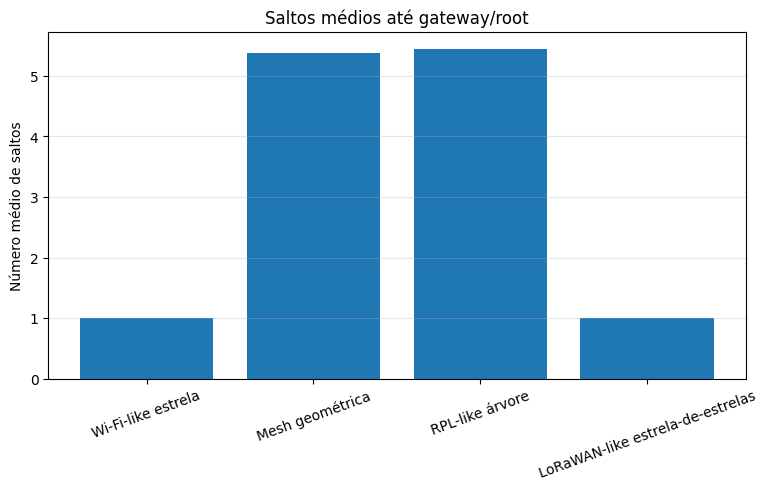

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison_df["model"], comparison_df["reachable_fraction"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fração de sensores alcançáveis")
ax.set_title("Cobertura por modelo")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison_df["model"], comparison_df["average_hops"])
ax.set_ylabel("Número médio de saltos")
ax.set_title("Saltos médios até gateway/root")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
plt.show()

Wi-Fi-like pode ser simples, mas exige alcance direto. Mesh aumenta cobertura por multi-hop quando a densidade ajuda. RPL-like ilustra uma estrutura de roteamento dentro da rede mesh. LoRaWAN-like usa longo alcance e múltiplos gateways, mas normalmente não encaminha mensagens entre sensores.

Também é importante separar os níveis conceituais:

- **mesh** é uma topologia/estratégia de conectividade;
- **Zigbee** é uma pilha local de comunicação;
- **RPL** é um protocolo de roteamento IPv6 para redes restritas;
- **LoRa** é tecnologia física/modulação;
- **LoRaWAN** é arquitetura/protocolo LPWAN.

Nenhuma alternativa é universalmente melhor. A melhor escolha depende das restrições do problema.

## 10. Explorando o efeito do raio de comunicação

Agora vamos variar o raio de comunicação da mesh. Isso ajuda a observar como cobertura e densidade de enlaces mudam quando cada nó consegue falar com vizinhos mais próximos ou mais distantes.

In [12]:
def sweep_radius_mesh(
    positions: np.ndarray, gateway: np.ndarray, radii: np.ndarray
) -> pd.DataFrame:
    '''
    Varre raios de comunicação para mesh.

    Para cada raio, constrói mesh e calcula:
    - reachable_fraction
    - average_hops
    - max_hops
    - number_of_edges
    - average_degree
    Retorna DataFrame.
    '''
    rows = []
    for radius in radii:
        G, gateway_id, _ = build_geometric_graph(positions, gateway, float(radius))
        stats = mesh_metrics(G, gateway_id, len(positions))
        rows.append(
            {
                "radius": float(radius),
                "reachable_fraction": stats["reachable_fraction"],
                "average_hops": stats["average_hops_to_gateway"],
                "max_hops": stats["max_hops_to_gateway"],
                "number_of_edges": stats["number_of_edges"],
                "average_degree": stats["average_degree"],
                "connected_components": stats["connected_components"],
            }
        )
    return pd.DataFrame(rows)


radii = np.arange(50, 251, 25)
sweep_df = sweep_radius_mesh(positions, gateway, radii)
sweep_df

,radius,reachable_fraction,average_hops,max_hops,number_of_edges,average_degree,connected_components
0,50.0,0.025,1.600000,3,162,1.611940,79
1,75.0,0.075,2.666667,6,345,3.432836,21
2,100.0,1.000,6.875000,14,570,5.671642,1
3,125.0,1.000,4.700000,8,888,8.835821,1
4,150.0,1.000,3.490000,6,1274,12.676617,1
5,175.0,1.000,2.950000,5,1707,16.985075,1
6,200.0,1.000,2.610000,4,2205,21.940299,1
7,225.0,1.000,2.250000,4,2682,26.686567,1
8,250.0,1.000,2.125000,4,3205,31.890547,1


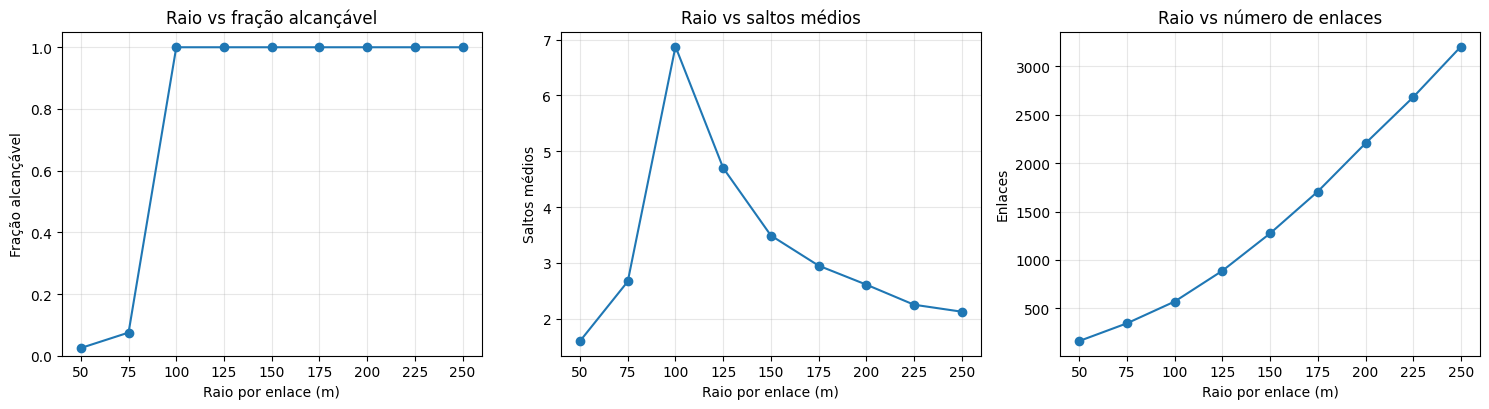

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(sweep_df["radius"], sweep_df["reachable_fraction"], marker="o")
axes[0].set_title("Raio vs fração alcançável")
axes[0].set_xlabel("Raio por enlace (m)")
axes[0].set_ylabel("Fração alcançável")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df["radius"], sweep_df["average_hops"], marker="o")
axes[1].set_title("Raio vs saltos médios")
axes[1].set_xlabel("Raio por enlace (m)")
axes[1].set_ylabel("Saltos médios")
axes[1].grid(True, alpha=0.3)

axes[2].plot(sweep_df["radius"], sweep_df["number_of_edges"], marker="o")
axes[2].set_title("Raio vs número de enlaces")
axes[2].set_xlabel("Raio por enlace (m)")
axes[2].set_ylabel("Enlaces")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Raios pequenos tendem a fragmentar a rede. Raios intermediários podem permitir multi-hop suficiente para alcançar o gateway. Raios grandes aumentam a conectividade, mas também elevam o número de enlaces possíveis.

Este notebook não simula contenção real, colisões ou consumo. Ainda assim, o crescimento do número de enlaces sugere qualitativamente que redes mais densas podem exigir mais coordenação e gerenciamento.

## 11. Extra opcional: tráfego simplificado com eventos

Esta seção é opcional. Se `simpy` estiver instalado, criaremos uma simulação discreta por eventos muito simples: poucos sensores geram pacotes em tempos aleatórios e um gateway registra chegadas.

Isso **não** é uma simulação física de rádio. Não há colisões reais, backoff, retransmissões, interferência ou perdas. O objetivo é apenas mostrar a ideia de mensagens assíncronas ao longo do tempo.

,sensor_id,arrival_time
0,4,1.037249
1,4,1.988779
2,3,3.357531
3,3,4.202767
4,4,14.547509
5,6,16.919528
6,3,17.271051
7,5,17.431926
8,5,19.277205
9,5,20.376132


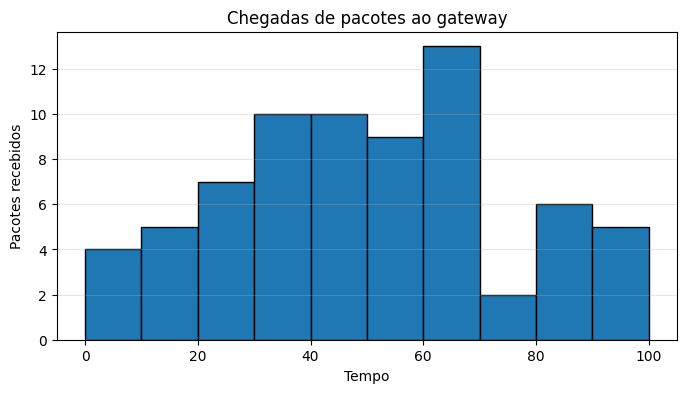

In [14]:
try:
    import simpy

    SIMPY_AVAILABLE = True
except ImportError:
    SIMPY_AVAILABLE = False
    print("SimPy não está instalado. Pule esta seção ou instale com pip install simpy.")


def run_optional_simpy_demo(
    n_demo_sensors: int = 8,
    simulation_time: float = 100.0,
    mean_interval: float = 12.0,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    '''Executa uma simulação simples de chegada de pacotes, se SimPy existir.'''
    if not SIMPY_AVAILABLE:
        return pd.DataFrame(columns=["sensor_id", "arrival_time"])

    local_rng = np.random.default_rng(seed)
    arrivals: list[dict[str, float | int]] = []

    def sensor_process(env: simpy.Environment, sensor_id: int) -> None:
        while True:
            delay = float(local_rng.exponential(mean_interval))
            yield env.timeout(delay)
            arrivals.append({"sensor_id": sensor_id, "arrival_time": float(env.now)})

    env = simpy.Environment()
    for sensor_id in range(n_demo_sensors):
        env.process(sensor_process(env, sensor_id))
    env.run(until=simulation_time)

    return pd.DataFrame(arrivals)


traffic_df = run_optional_simpy_demo()

if SIMPY_AVAILABLE:
    display(traffic_df.head(10))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(traffic_df["arrival_time"], bins=np.arange(0, 105, 10), edgecolor="black")
    ax.set_title("Chegadas de pacotes ao gateway")
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Pacotes recebidos")
    ax.grid(axis="y", alpha=0.3)
    plt.show()
else:
    display(traffic_df)

## 12. Conclusões

1. A escolha da tecnologia de rede em IoT depende das restrições do problema.
2. Redes estrela são simples, mas dependem de alcance direto.
3. Redes mesh permitem multi-hop e aumentam cobertura local, mas introduzem custo de roteamento, latência e consumo nos nós roteadores.
4. Zigbee pode ser entendido como uma tecnologia local de baixo consumo frequentemente associada a mesh, mas possui uma pilha própria.
5. RPL é um protocolo de roteamento IPv6 para redes de baixa potência e perdas; a árvore RPL-like do notebook é apenas uma abstração didática.
6. LoRaWAN segue uma lógica diferente: longo alcance e baixa taxa em topologia estrela-de-estrelas, normalmente sem mesh.